# Import Modules

In [1]:
import pathlib
import numpy as np
from matplotlib import pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing

In [ ]:
"""
Import more if you want
"""

'\nImport more if you want\n'

In [2]:
"""
Make sure your runtime type is GPU!
"""
physical_devices = tf.config.list_physical_devices('GPU')
print('Num_GPUs:{}, List:{}'.format(len(physical_devices), physical_devices))

Num_GPUs:1, List:[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Utils

In [3]:
def plot_dataset(images, labels, grid_width, grid_height, figure_width=5, figure_height=5, y_hats=None):
    """
    Plots image and labels.

    Do NOT modify this method.
    """
    f, ax = plt.subplots(grid_height, grid_width)
    f.set_size_inches(figure_width, figure_height)
    img_idx = 0
    for i in range(0, grid_height):
        for j in range(0, grid_width):
            image = images[img_idx]
            label = labels[img_idx]
            title_color = 'k'
            if y_hats is None:
                label_idx = int(label)
            else:
                label_idx = int(y_hats[img_idx])
                if int(labels[img_idx]) != label_idx:
                    title_color = 'r'
            label = get_label_name(label_idx)
            ax[i][j].axis('off')
            ax[i][j].set_title(label, color=title_color)
            ax[i][j].imshow(image, aspect='auto')
            img_idx += 1
        plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0.25)
    plt.show()

def plot_history(history):
    """
    Plots training history.
    
    Do NOT modify this method.
    """
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Test'], loc='upper left')
    plt.show()
    
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Test'], loc='upper left')
    plt.show()

# TF Flowers Dataset

### Load raw data

In [4]:
(raw_train_ds, raw_valid_ds, raw_test_ds), info = tfds.load('tf_flowers',
                                                            split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'], 
                                                            data_dir = './',
                                                            with_info=True, 
                                                            as_supervised=True)
num_classes = info.features['label'].num_classes
label_names = info.features['label'].names
get_label_name = info.features['label'].int2str

local data directory. If you'd instead prefer to read directly from our public
GCS bucket (recommended if you're running on GCP), you can instead pass
`try_gcs=True` to `tfds.load` or set `data_dir=gs://tfds-data/datasets`.



Dl Completed...:   0%|          | 0/5 [00:00<?, ? file/s]


Dataset tf_flowers downloaded and prepared to ./tf_flowers/3.0.1. Subsequent calls will reuse this data.


### Preprocess images

In [5]:
def preprocess(ds, img_shape=(64, 64, 3)):
    """
    Resize the image to the given shape and apply normalization
    """
    resizer = preprocessing.Resizing(height=img_shape[0], width=img_shape[1])
    rescaler = preprocessing.Rescaling(1. / 255)
    def map_func(x):
        x = resizer(x)
        x = rescaler(x)
        return x
    return ds.map(lambda x, y: (map_func(x), y))

In [6]:
"""
Apply preprocess to TF datasets
"""
img_shape = (64, 64, 3)

train_ds_preprocessed = preprocess(raw_train_ds, img_shape)
valid_ds_preprocessed = preprocess(raw_valid_ds, img_shape)
test_ds_preprocessed = preprocess(raw_test_ds, img_shape)

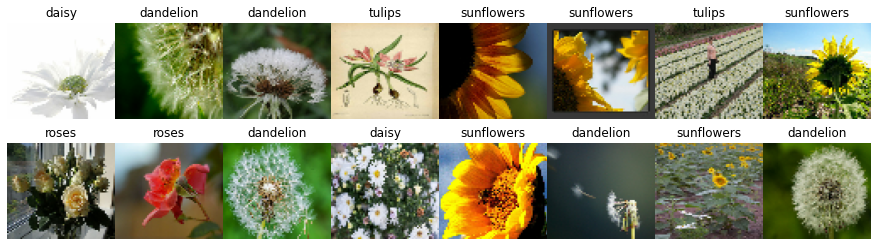

In [7]:
"""
Take a batch and plot images
"""
images, labels = next(iter(train_ds_preprocessed.shuffle(100).batch(16)))
plot_dataset(images, labels, grid_width=8, grid_height=2, figure_width=12, figure_height=3)

# Data Augmentation

In [8]:
###
# Question (a)
# Build your own augmentation layer.
# - use TF preprocessing layers to build an image augmentation layer.
# - use at least three methods.
# - for random cropping, you can combine it with resizing to preserve the image size(These will be counted as two methods)
# - for the supported methods, refer to https://www.tensorflow.org/api_docs/python/tf/keras/layers/experimental/preprocessing
###

In [9]:
augmentation_layer = tf.keras.Sequential(
    [
        # Your code here
        preprocessing.RandomFlip("horizontal"), # 상하좌우 뒤집기
        preprocessing.RandomRotation(0.1), # 회전
        preprocessing.RandomZoom(0.1), # 줌        
    ],
    name='augmentation_layers')

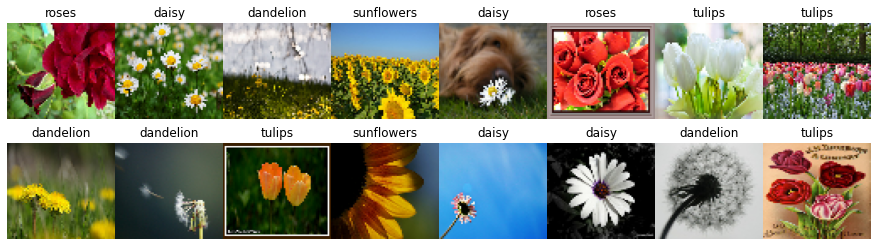

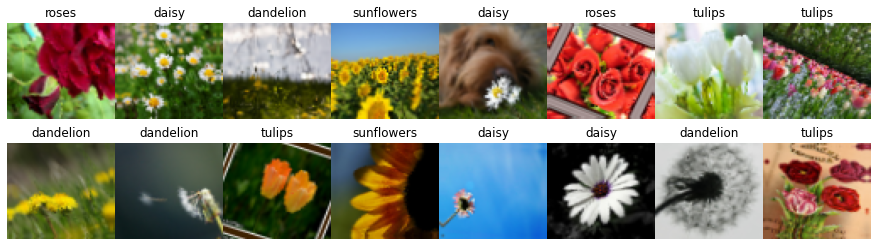

In [10]:
"""
Take a batch and plot augmented images
"""
images, labels = next(iter(train_ds_preprocessed.shuffle(100).batch(16)))
images_augmented = augmentation_layer(images)
plot_dataset(images, labels, grid_width=8, grid_height=2, figure_width=12, figure_height=3)
plot_dataset(images_augmented, labels, grid_width=8, grid_height=2, figure_width=12, figure_height=3)

# ConvNet

In [11]:
###
# Question (b)
# Use Tensorflow Sequential API to build a ConvNet.
# - don't forget to use InputLayer.
# - use your augmentation_layer implemented above.
# - use a Flatten layer before dense layers.
#
# - refer to the link below to see usages.
# - for the convolution layer, https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D
# - for the pooling layer, https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D
# - for the fully connected layer, https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense
# - refer to TF tutorials for further information.
###

In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    augmentation_layer,
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

In [13]:
###
# Question (c)
# Train your ConvNet to achieve TEST accuracy over 70%.
###

In [14]:
"""
Modify as you want
"""
batch_size = 64
epochs = 20

train_ds = train_ds_preprocessed.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
valid_ds = valid_ds_preprocessed.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds_preprocessed.batch(batch_size).prefetch(tf.data.AUTOTUNE)

tf.keras.backend.clear_session()
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics='accuracy')

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        896       
                                                                 
 augmentation_layers (Sequen  (None, None, None, None)  0        
 tial)                                                           
                                                                 
 max_pooling2d (MaxPooling2D  (None, 31, 31, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                        

Epoch 1/20
46/46 [==============================] - 22s 102ms/step - loss: 1.4476 - accuracy: 0.3617 - val_loss: 1.1875 - val_accuracy: 0.4877
Epoch 2/20
46/46 [==============================] - 2s 41ms/step - loss: 1.1789 - accuracy: 0.5058 - val_loss: 1.3590 - val_accuracy: 0.4932
Epoch 3/20
46/46 [==============================] - 2s 40ms/step - loss: 1.0931 - accuracy: 0.5521 - val_loss: 1.0186 - val_accuracy: 0.5749
Epoch 4/20
46/46 [==============================] - 2s 41ms/step - loss: 0.9926 - accuracy: 0.6110 - val_loss: 1.1028 - val_accuracy: 0.5858
Epoch 5/20
46/46 [==============================] - 2s 43ms/step - loss: 0.9614 - accuracy: 0.6206 - val_loss: 0.9524 - val_accuracy: 0.6322
Epoch 6/20
46/46 [==============================] - 2s 41ms/step - loss: 0.9314 - accuracy: 0.6298 - val_loss: 1.0402 - val_accuracy: 0.6022
Epoch 7/20
46/46 [==============================] - 2s 43ms/step - loss: 0.8801 - accuracy: 0.6580 - val_loss: 1.0603 - val_accuracy: 0.6158
Epoch 8/20


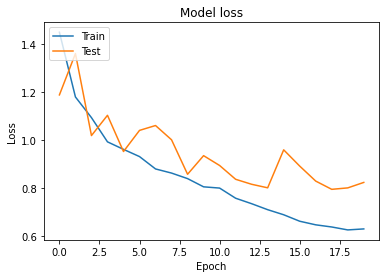

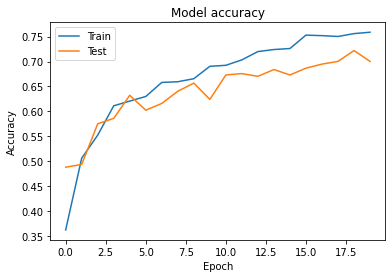

In [15]:
"""
Training
"""
history = model.fit(train_ds, validation_data=valid_ds, epochs=epochs)
plot_history(history)

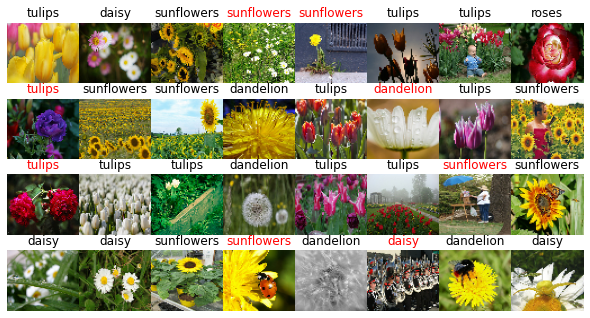

6/6 [==============================] - 0s 15ms/step - loss: 0.7786 - accuracy: 0.7030
Final test accuracy: 0.7029972672462463


In [16]:
"""
Evaluation
"""
images, labels = next(iter(test_ds_preprocessed.shuffle(500).batch(32).take(1)))
y_hats = np.argmax(model.predict(images), axis=1)
plot_dataset(images, labels, grid_width=8, grid_height=4, figure_width=8, figure_height=4, y_hats=y_hats)

test_loss, test_acc = model.evaluate(test_ds)
print('Final test accuracy: {}'.format(test_acc))